# Problem 4 — Statement 3
## Theo dõi tiến trình và xu hướng đóng góp doanh số của từng nhân viên qua chuỗi thời gian, đánh giá mức độ ổn định

**Đề bài:** *Theo dõi tiến trình và xu hướng đóng góp doanh số của từng nhân viên qua chuỗi thời gian nhằm đánh giá mức độ ổn định trong công việc.*

**Nguồn dữ liệu (silver, đã chuẩn hóa 3NF):**
- `ORDER` (order_id PK; FK: customer_id, zip, sales_employee_id; order_date, order_status, device_type, order_source)
- `ORDER_ITEMS` (order_id + product_id PK; quantity, unit_price, discount_amount)

**Framework áp dụng:** Measure → Metric → KPI
| Bước | Nội dung |
|---|---|
| Measure | `quantity`, `unit_price`, `discount_amount` (ORDER_ITEMS); `order_id`, `order_date`, `order_status`, `sales_employee_id` (ORDER) |
| Metric | Doanh số theo (nhân viên, tháng); số hóa đơn theo (nhân viên, tháng); tăng trưởng MoM; **tỷ trọng đóng góp của nhân viên trong doanh số toàn hệ thống cùng tháng** |
| KPI | Xu hướng tỷ trọng đóng góp (%/tháng) và p-value; hệ số biến động (CV) của tỷ trọng; phân loại mức độ ổn định |

**Điểm khác so với phiên bản trước:** đo trên *tỷ trọng đóng góp* thay vì doanh số tuyệt đối, và phân loại theo luật thống kê thay vì chia theo phân vị. Lý do được giải thích ở mục 5b và 6.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.figsize"] = (11, 5)

## 1. Load dữ liệu (silver layer)

In [2]:
ORDER_PATH = "../../silver_data/ORDER.csv"
ORDER_ITEMS_PATH = "../../silver_data/ORDER_ITEMS.csv"

df_order = pd.read_csv(ORDER_PATH, parse_dates=["order_date"])
df_items = pd.read_csv(ORDER_ITEMS_PATH)

print("ORDER:", df_order.shape)
print("ORDER_ITEMS:", df_items.shape)
print("Khoảng thời gian:", df_order["order_date"].min(), "->", df_order["order_date"].max())
print("Số nhân viên:", df_order["sales_employee_id"].nunique())

ORDER: (646945, 8)
ORDER_ITEMS: (714653, 5)
Khoảng thời gian: 2012-07-04 00:00:00 -> 2022-12-31 00:00:00
Số nhân viên: 200


## 2. Khám phá sơ bộ dữ liệu

In [3]:
display(df_order.head())
display(df_items.head())

print(df_order["order_status"].value_counts(dropna=False))

,order_id,order_date,customer_id,zip,order_status,device_type,order_source,sales_employee_id
0,1,2012-07-04,58578,1109,delivered,desktop,paid_search,EMP0103
1,2,2012-07-04,58621,1330,returned,mobile,paid_search,EMP0180
2,3,2012-07-04,58811,1473,delivered,desktop,direct,EMP0093
3,4,2012-07-04,59453,2360,delivered,desktop,referral,EMP0015
4,6,2012-07-06,57821,2886,delivered,mobile,email_campaign,EMP0107


,order_id,product_id,quantity,unit_price,discount_amount
0,1,2400,7,"1,138.2200",0.0000
1,2,609,7,"10,166.2500",0.0000
2,3,396,3,"11,220.3300",0.0000
3,4,635,5,"10,639.2500",0.0000
4,6,1935,1,"1,597.8400",0.0000


order_status
delivered    516716
cancelled     59462
returned      36142
shipped       13773
paid          13577
created        7275
Name: count, dtype: int64


## 3. Xác định Measure

| Bảng | Measure | Ý nghĩa |
|---|---|---|
| ORDER | `sales_employee_id` | Chiều phân tích — nhân viên bán hàng |
| ORDER | `order_date` | Chiều phân tích — thời gian (sẽ quy về tháng) |
| ORDER | `order_status` | Lọc đơn hàng xử lý thành công |
| ORDER | `order_id` | Định danh hóa đơn |
| ORDER_ITEMS | `quantity`, `unit_price`, `discount_amount` | Tính doanh thu từng dòng hàng |

Measure dẫn xuất: `doanh_thu_dong = quantity * unit_price - discount_amount`.

In [4]:
df_items["doanh_thu_dong"] = (
    df_items["quantity"] * df_items["unit_price"] - df_items["discount_amount"]
)

## 4. Lọc hóa đơn "xử lý thành công"

Theo dữ liệu thực tế, `order_status` có các giá trị: `delivered`, `cancelled`, `returned`,
`shipped`, `paid`, `created`. Ở đây coi **`delivered`** là trạng thái xử lý thành công
(thống nhất với PS1, PS2 và PS5; cần đối chiếu lại với nghiệp vụ thực tế của nhóm nếu định nghĩa khác).

In [5]:
SUCCESSFUL_STATUSES = ["delivered"]

df_order_success = df_order[df_order["order_status"].isin(SUCCESSFUL_STATUSES)].copy()
df_order_success["order_month"] = df_order_success["order_date"].dt.to_period("M").dt.to_timestamp()

print(f"Số đơn hàng thành công: {len(df_order_success):,} / {len(df_order):,}")

Số đơn hàng thành công: 516,716 / 646,945


## 5. Xây dựng Metric

Nối `ORDER_ITEMS` với các đơn hàng thành công, sau đó tổng hợp doanh số và số hóa đơn
theo cặp (`sales_employee_id`, `order_month`) — đây là chuỗi thời gian cho từng nhân viên.

Bổ sung **tỷ trọng đóng góp** (`ty_trong`): doanh số của nhân viên trong tháng chia cho tổng doanh số của
toàn bộ nhân viên trong cùng tháng. Đề bài hỏi về *xu hướng đóng góp*, và chỉ số này đo đúng điều đó: nó đã
loại bỏ ảnh hưởng chung của hệ thống (xu hướng giảm, mùa vụ) để chỉ còn phần khác biệt của riêng từng nhân viên.

In [6]:
df_merged = df_items.merge(
    df_order_success[["order_id", "sales_employee_id", "order_month"]],
    on="order_id",
    how="inner",
)

monthly_metric = (
    df_merged.groupby(["sales_employee_id", "order_month"])
    .agg(
        doanh_so_thang=("doanh_thu_dong", "sum"),
        so_hoa_don_thang=("order_id", "nunique"),
    )
    .reset_index()
    .sort_values(["sales_employee_id", "order_month"])
)

# Tăng trưởng doanh số theo tháng (Month-over-Month) cho từng nhân viên
monthly_metric["doanh_so_thang_truoc"] = (
    monthly_metric.groupby("sales_employee_id")["doanh_so_thang"].shift(1)
)
monthly_metric["tang_truong_mom_%"] = (
    (monthly_metric["doanh_so_thang"] - monthly_metric["doanh_so_thang_truoc"])
    / monthly_metric["doanh_so_thang_truoc"] * 100
)

# Tỷ trọng đóng góp của nhân viên trong doanh số toàn hệ thống cùng tháng
monthly_metric["doanh_so_he_thong"] = (
    monthly_metric.groupby("order_month")["doanh_so_thang"].transform("sum")
)
monthly_metric["ty_trong"] = monthly_metric["doanh_so_thang"] / monthly_metric["doanh_so_he_thong"]

monthly_metric.head(10)

,sales_employee_id,order_month,doanh_so_thang,so_hoa_don_thang,doanh_so_thang_truoc,tang_truong_mom_%,doanh_so_he_thong,ty_trong
0,EMP0001,2012-07-01,"572,821.5000",19,NaN,NaN,"104,964,326.1600",0.0055
1,EMP0001,2012-08-01,"490,202.9900",19,"572,821.5000",-14.4231,"127,134,581.2000",0.0039
2,EMP0001,2012-09-01,"326,309.0300",19,"490,202.9900",-33.4339,"101,921,827.5900",0.0032
3,EMP0001,2012-10-01,"295,236.1400",19,"326,309.0300",-9.5225,"87,177,259.3500",0.0034
4,EMP0001,2012-11-01,"447,654.2100",18,"295,236.1400",51.6258,"77,034,638.4800",0.0058
5,EMP0001,2012-12-01,"325,866.9200",24,"447,654.2100",-27.2057,"92,785,761.1000",0.0035
6,EMP0001,2013-01-01,"566,364.6600",18,"325,866.9200",73.8024,"73,459,925.2300",0.0077
7,EMP0001,2013-02-01,"381,735.1900",13,"566,364.6600",-32.5990,"85,407,207.7400",0.0045
8,EMP0001,2013-03-01,"566,303.7300",24,"381,735.1900",48.3499,"116,509,900.4100",0.0049
9,EMP0001,2013-04-01,"561,604.7300",31,"566,303.7300",-0.8298,"154,668,158.0000",0.0036


## 5b. Bối cảnh toàn hệ thống

Trước khi đánh giá từng nhân viên cần biết hệ thống đang vận động ra sao, vì mọi nhân viên đều chịu cùng
một xu hướng chung và cùng một mùa vụ. Nếu bỏ qua bước này, "xu hướng giảm" của từng người thực chất chỉ phản ánh
xu hướng giảm của cả hệ thống.

Xu hướng toàn hệ thống: -0.535 %/tháng (126 tháng)


,tong_doanh_so,so_thang,doanh_so_tb_thang
order_month,,,
2012,"591,018,394",6,"98,503,066"
2013,"1,284,784,389",12,"107,065,366"
2014,"1,457,974,988",12,"121,497,916"
2015,"1,463,728,946",12,"121,977,412"
2016,"1,645,705,629",12,"137,142,136"
2017,"1,489,910,501",12,"124,159,208"
2018,"1,439,977,373",12,"119,998,114"
2019,"876,833,653",12,"73,069,471"
2020,"813,914,380",12,"67,826,198"


order_month,1,2,3,4,5,6,7,8,9,10,11,12
chi_so_mua_vu,0.6200,0.7600,1.1500,1.4800,1.5900,1.4800,1.0700,1.0700,0.8400,0.7900,0.5900,0.5600


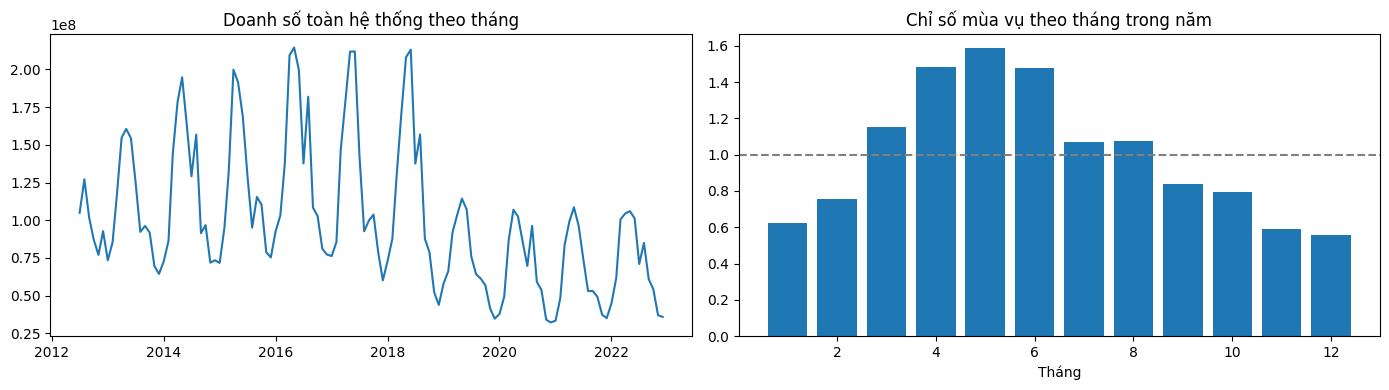

In [7]:
system_monthly = monthly_metric.groupby("order_month")["doanh_so_thang"].sum()

# Xu hướng tuyến tính của toàn hệ thống (%/tháng, so với doanh số trung bình tháng)
sys_slope = np.polyfit(np.arange(len(system_monthly)), system_monthly.values, 1)[0]
SYS_TREND_PCT = sys_slope / system_monthly.mean() * 100
print(f"Xu hướng toàn hệ thống: {SYS_TREND_PCT:.3f} %/tháng ({len(system_monthly)} tháng)")

# Doanh số theo năm (lưu ý năm đầu chỉ có một phần số tháng nên so sánh theo trung bình tháng)
annual = system_monthly.groupby(system_monthly.index.year).agg(tong_doanh_so="sum", so_thang="count")
annual["doanh_so_tb_thang"] = annual["tong_doanh_so"] / annual["so_thang"]
display(annual.style.format({"tong_doanh_so": "{:,.0f}", "doanh_so_tb_thang": "{:,.0f}"}))

# Chỉ số mùa vụ: doanh số trung bình của từng tháng trong năm / trung bình chung
moy = system_monthly.groupby(system_monthly.index.month).mean()
seasonal_index = (moy / moy.mean()).rename("chi_so_mua_vu")
display(seasonal_index.to_frame().T.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(system_monthly.index, system_monthly.values)
axes[0].set_title("Doanh số toàn hệ thống theo tháng")
axes[1].bar(seasonal_index.index, seasonal_index.values)
axes[1].axhline(1, color="gray", linestyle="--")
axes[1].set_title("Chỉ số mùa vụ theo tháng trong năm")
axes[1].set_xlabel("Tháng")
plt.tight_layout()
plt.show()

## 6. Xây dựng KPI đánh giá mức độ ổn định

Tất cả KPI chính được tính trên chuỗi **tỷ trọng đóng góp** (`ty_trong`) của từng nhân viên:

- **Xu hướng tỷ trọng (%/tháng)** (`xu_huong_ty_trong_%_thang`) — hệ số góc hồi quy tuyến tính của `ty_trong` theo thứ tự tháng,
  chia cho tỷ trọng trung bình. Dương = đóng góp đang tăng so với đồng nghiệp, âm = đang giảm, gần 0 = giữ nguyên vị thế.
- **p-value** (`p_value`) — kiểm định độ dốc khác 0. Có 126 điểm nhưng dữ liệu nhiễu nên phần lớn độ dốc nhỏ chỉ là dao động ngẫu nhiên;
  p-value cho biết xu hướng nào đủ rõ để tin.
- **Hệ số biến động — CV** (`cv_ty_trong = std/mean` của `ty_trong`) — mức dao động tương đối của tỷ trọng đóng góp. Đo trên tỷ trọng nên không còn bị
  mùa vụ và cú giảm chung của hệ thống làm phình lên.
- Giữ thêm các chỉ số trên doanh số tuyệt đối (`doanh_so_tb_thang`, `cv_doanh_so`, `xu_huong_doanh_so_%_thang`) **chỉ để tham khảo/đối chiếu với báo cáo cũ**.

**Luật phân loại** (xét theo thứ tự ưu tiên, mỗi nhân viên thuộc đúng một nhóm):

| Thứ tự | Điều kiện | Nhóm |
|---|---|---|
| 1 | `p_value < 0.05` và xu hướng tỷ trọng < 0 | **Suy giảm rõ rệt** |
| 2 | `p_value < 0.05` và xu hướng tỷ trọng > 0 | **Tăng trưởng** |
| 3 | CV của tỷ trọng cao hơn trung bình ít nhất 1 độ lệch chuẩn (z > 1) | **Biến động mạnh** |
| 4 | Còn lại | **Ổn định** |

**Lưu ý khi diễn giải:** với ngưỡng 5% và 200 nhân viên, riêng yếu tố ngẫu nhiên đã cho khoảng 10 người "có ý nghĩa". Vì vậy hai nhóm
*Tăng trưởng* và *Suy giảm rõ rệt* nên được hiểu là **nhóm cần theo dõi**, chưa đủ cơ sở để áp dụng thưởng/phạt.

In [8]:
P_THRESHOLD = 0.05   # mức ý nghĩa thống kê cho xu hướng
CV_Z_THRESHOLD = 1   # CV cao hơn trung bình bao nhiêu độ lệch chuẩn thì coi là biến động mạnh

rows = []
for emp_id, g in monthly_metric.sort_values("order_month").groupby("sales_employee_id"):
    t = np.arange(len(g))
    reg_share = stats.linregress(t, g["ty_trong"].values)
    slope_abs = np.polyfit(t, g["doanh_so_thang"].values, 1)[0]
    rows.append({
        "sales_employee_id": emp_id,
        "so_thang_hoat_dong": len(g),
        "ty_trong_tb_%": g["ty_trong"].mean() * 100,
        "cv_ty_trong": g["ty_trong"].std() / g["ty_trong"].mean(),
        "xu_huong_ty_trong_%_thang": reg_share.slope / g["ty_trong"].mean() * 100,
        "p_value": reg_share.pvalue,
        "r_squared": reg_share.rvalue ** 2,
        # Chỉ số trên doanh số tuyệt đối, giữ lại để đối chiếu
        "doanh_so_tb_thang": g["doanh_so_thang"].mean(),
        "cv_doanh_so": g["doanh_so_thang"].std() / g["doanh_so_thang"].mean(),
        "xu_huong_doanh_so_%_thang": slope_abs / g["doanh_so_thang"].mean() * 100,
    })

stability = pd.DataFrame(rows)
stability["xu_huong_so_voi_he_thong"] = stability["xu_huong_doanh_so_%_thang"] - SYS_TREND_PCT

stability.head(10)

,sales_employee_id,so_thang_hoat_dong,ty_trong_tb_%,cv_ty_trong,xu_huong_ty_trong_%_thang,p_value,r_squared,doanh_so_tb_thang,cv_doanh_so,xu_huong_doanh_so_%_thang,xu_huong_so_voi_he_thong
0,EMP0001,126,0.4957,0.3802,0.0221,0.8136,0.0005,"496,310.8345",0.5383,-0.5130,0.0219
1,EMP0002,126,0.5140,0.3257,0.0433,0.5889,0.0024,"515,609.0262",0.5079,-0.4894,0.0454
2,EMP0003,126,0.4825,0.3025,-0.0103,0.8905,0.0002,"495,508.6702",0.5614,-0.5162,0.0187
3,EMP0004,126,0.5058,0.3256,0.1300,0.1032,0.0213,"500,475.2263",0.5539,-0.4677,0.0671
4,EMP0005,126,0.4919,0.3495,0.0646,0.4527,0.0046,"495,270.9159",0.5525,-0.4470,0.0879
5,EMP0006,126,0.5121,0.3250,0.0726,0.3638,0.0067,"510,142.8184",0.5075,-0.4801,0.0548
6,EMP0007,126,0.4946,0.3784,0.0044,0.9626,0.0000,"502,372.2919",0.5960,-0.5276,0.0072
7,EMP0008,126,0.5060,0.4188,0.1366,0.1840,0.0142,"500,437.1229",0.5487,-0.4062,0.1286
8,EMP0009,126,0.4961,0.3163,0.0239,0.7591,0.0008,"499,786.4275",0.5661,-0.5297,0.0051
9,EMP0010,126,0.5023,0.3565,-0.0229,0.7947,0.0005,"503,908.4735",0.5228,-0.5556,-0.0208


In [9]:
cv_z = (stability["cv_ty_trong"] - stability["cv_ty_trong"].mean()) / stability["cv_ty_trong"].std()
significant = stability["p_value"] < P_THRESHOLD
trend = stability["xu_huong_ty_trong_%_thang"]

stability["phan_loai_on_dinh"] = np.select(
    [significant & (trend < 0), significant & (trend > 0), cv_z > CV_Z_THRESHOLD],
    ["Suy giảm rõ rệt", "Tăng trưởng", "Biến động mạnh"],
    default="Ổn định",
)
stability = stability.sort_values("ty_trong_tb_%", ascending=False).reset_index(drop=True)

print(stability["phan_loai_on_dinh"].value_counts())
print()
print(f"Số nhân viên có p < {P_THRESHOLD}: {significant.sum()} / {len(stability)}")
print(f"Số nhân viên 'có ý nghĩa' kỳ vọng do ngẫu nhiên: ~{P_THRESHOLD * len(stability):.0f}")

phan_loai_on_dinh
Ổn định            151
Biến động mạnh      33
Tăng trưởng         10
Suy giảm rõ rệt      6
Name: count, dtype: int64

Số nhân viên có p < 0.05: 16 / 200
Số nhân viên 'có ý nghĩa' kỳ vọng do ngẫu nhiên: ~10


## 7. Trực quan hóa

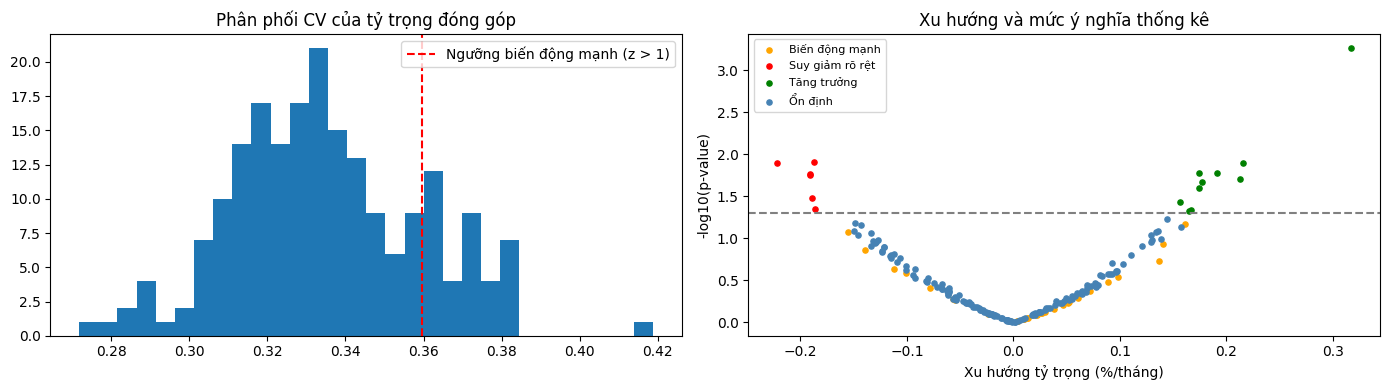

In [10]:
# Phân phối CV và xu hướng tỷ trọng để kiểm tra lại ngưỡng phân loại ở bước 6
cv_threshold_value = stability["cv_ty_trong"].mean() + CV_Z_THRESHOLD * stability["cv_ty_trong"].std()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(stability["cv_ty_trong"], bins=30)
axes[0].axvline(cv_threshold_value, color="red", linestyle="--", label=f"Ngưỡng biến động mạnh (z > {CV_Z_THRESHOLD})")
axes[0].set_title("Phân phối CV của tỷ trọng đóng góp")
axes[0].legend()

colors = {"Suy giảm rõ rệt": "red", "Tăng trưởng": "green", "Biến động mạnh": "orange", "Ổn định": "steelblue"}
for name, grp in stability.groupby("phan_loai_on_dinh"):
    axes[1].scatter(grp["xu_huong_ty_trong_%_thang"], -np.log10(grp["p_value"]), s=14, label=name, color=colors[name])
axes[1].axhline(-np.log10(P_THRESHOLD), color="gray", linestyle="--")
axes[1].set_xlabel("Xu hướng tỷ trọng (%/tháng)")
axes[1].set_ylabel("-log10(p-value)")
axes[1].set_title("Xu hướng và mức ý nghĩa thống kê")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

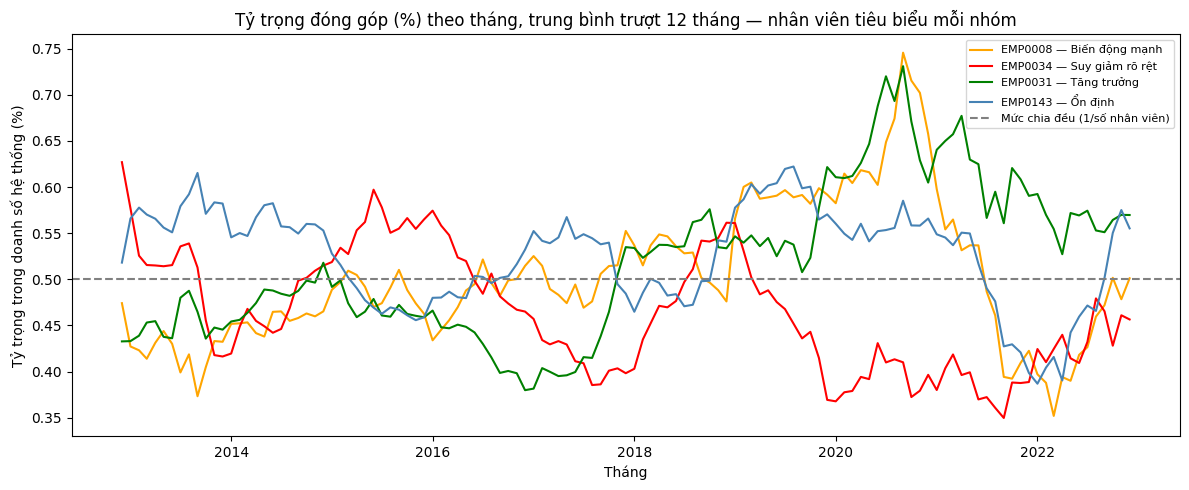

In [11]:
# Tỷ trọng đóng góp theo tháng (làm mượt 12 tháng) của nhân viên tiêu biểu mỗi nhóm
# (tiêu biểu = nhân viên có |xu hướng tỷ trọng| lớn nhất trong nhóm Tăng trưởng/Suy giảm; CV cao nhất trong nhóm Biến động mạnh; gần trung vị trong nhóm Ổn định)
picks = {}
for name, grp in stability.groupby("phan_loai_on_dinh"):
    if name in ("Tăng trưởng", "Suy giảm rõ rệt"):
        picks[name] = grp.loc[grp["xu_huong_ty_trong_%_thang"].abs().idxmax(), "sales_employee_id"]
    elif name == "Biến động mạnh":
        picks[name] = grp.loc[grp["cv_ty_trong"].idxmax(), "sales_employee_id"]
    else:
        picks[name] = grp.loc[(grp["cv_ty_trong"] - grp["cv_ty_trong"].median()).abs().idxmin(), "sales_employee_id"]

fig, ax = plt.subplots(figsize=(12, 5))
for name, emp_id in picks.items():
    s = monthly_metric[monthly_metric["sales_employee_id"] == emp_id].set_index("order_month")["ty_trong"] * 100
    ax.plot(s.index, s.rolling(12, min_periods=6).mean(), label=f"{emp_id} — {name}", color=colors[name])
ax.axhline(100 / stability.shape[0], color="gray", linestyle="--", label="Mức chia đều (1/số nhân viên)")
ax.set_title("Tỷ trọng đóng góp (%) theo tháng, trung bình trượt 12 tháng — nhân viên tiêu biểu mỗi nhóm")
ax.set_xlabel("Tháng")
ax.set_ylabel("Tỷ trọng trong doanh số hệ thống (%)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

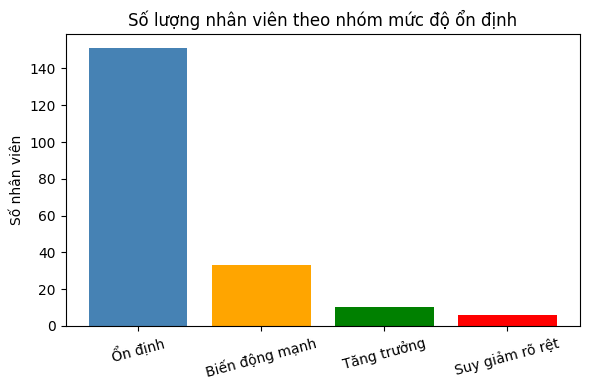

In [12]:
# Số lượng nhân viên theo từng nhóm phân loại ổn định
counts = stability["phan_loai_on_dinh"].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index, counts.values, color=[colors[c] for c in counts.index])
ax.set_title("Số lượng nhân viên theo nhóm mức độ ổn định")
ax.set_ylabel("Số nhân viên")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 8. Danh sách đưa vào báo cáo và xuất kết quả

Hai bảng dưới thay thế danh sách "5 nhân viên suy giảm mạnh nhất" của phiên bản trước: xếp theo xu hướng *tỷ trọng đóng góp*
(đã loại bỏ xu hướng chung của hệ thống) và kèm p-value để người đọc thấy mức độ chắc chắn.

In [13]:
cols_report = ["sales_employee_id", "ty_trong_tb_%", "cv_ty_trong", "xu_huong_ty_trong_%_thang", "p_value", "phan_loai_on_dinh"]

print("5 nhân viên có tỷ trọng đóng góp giảm nhiều nhất:")
display(stability.nsmallest(5, "xu_huong_ty_trong_%_thang")[cols_report])

print("5 nhân viên có tỷ trọng đóng góp tăng nhiều nhất:")
display(stability.nlargest(5, "xu_huong_ty_trong_%_thang")[cols_report])

5 nhân viên có tỷ trọng đóng góp giảm nhiều nhất:


,sales_employee_id,ty_trong_tb_%,cv_ty_trong,xu_huong_ty_trong_%_thang,p_value,phan_loai_on_dinh
198,EMP0034,0.4614,0.3656,-0.2218,0.0127,Suy giảm rõ rệt
162,EMP0102,0.4879,0.3309,-0.1912,0.0177,Suy giảm rõ rệt
121,EMP0186,0.4958,0.3275,-0.1905,0.0169,Suy giảm rõ rệt
196,EMP0193,0.4637,0.3629,-0.1891,0.0328,Suy giảm rõ rệt
183,EMP0153,0.4807,0.3075,-0.1876,0.0121,Suy giảm rõ rệt


5 nhân viên có tỷ trọng đóng góp tăng nhiều nhất:


,sales_employee_id,ty_trong_tb_%,cv_ty_trong,xu_huong_ty_trong_%_thang,p_value,phan_loai_on_dinh
10,EMP0031,0.5213,0.3808,0.3172,0.0005,Tăng trưởng
143,EMP0159,0.4907,0.3545,0.2153,0.0126,Tăng trưởng
29,EMP0144,0.5157,0.3746,0.2130,0.0197,Tăng trưởng
76,EMP0138,0.5051,0.3269,0.1911,0.0164,Tăng trưởng
74,EMP0090,0.5058,0.3168,0.1775,0.0215,Tăng trưởng


In [14]:
OUTPUT_DIR = "../output"
OUTPUT_MONTHLY = f"{OUTPUT_DIR}/PS3_monthly_by_employee.csv"
OUTPUT_STABILITY = f"{OUTPUT_DIR}/PS3_stability_kpi.csv"
os.makedirs(OUTPUT_DIR, exist_ok=True)

monthly_metric.to_csv(OUTPUT_MONTHLY, index=False)
stability.to_csv(OUTPUT_STABILITY, index=False)

print(f"Đã lưu chuỗi thời gian theo tháng vào: {OUTPUT_MONTHLY}")
print(f"Đã lưu bảng KPI ổn định vào: {OUTPUT_STABILITY}")

Đã lưu chuỗi thời gian theo tháng vào: ../output/PS3_monthly_by_employee.csv
Đã lưu bảng KPI ổn định vào: ../output/PS3_stability_kpi.csv
